<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Electrical_Schematic_Example_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [6]:
!pip install -q uv
!uv pip install --system schemdraw matplotlib numpy

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 51ms


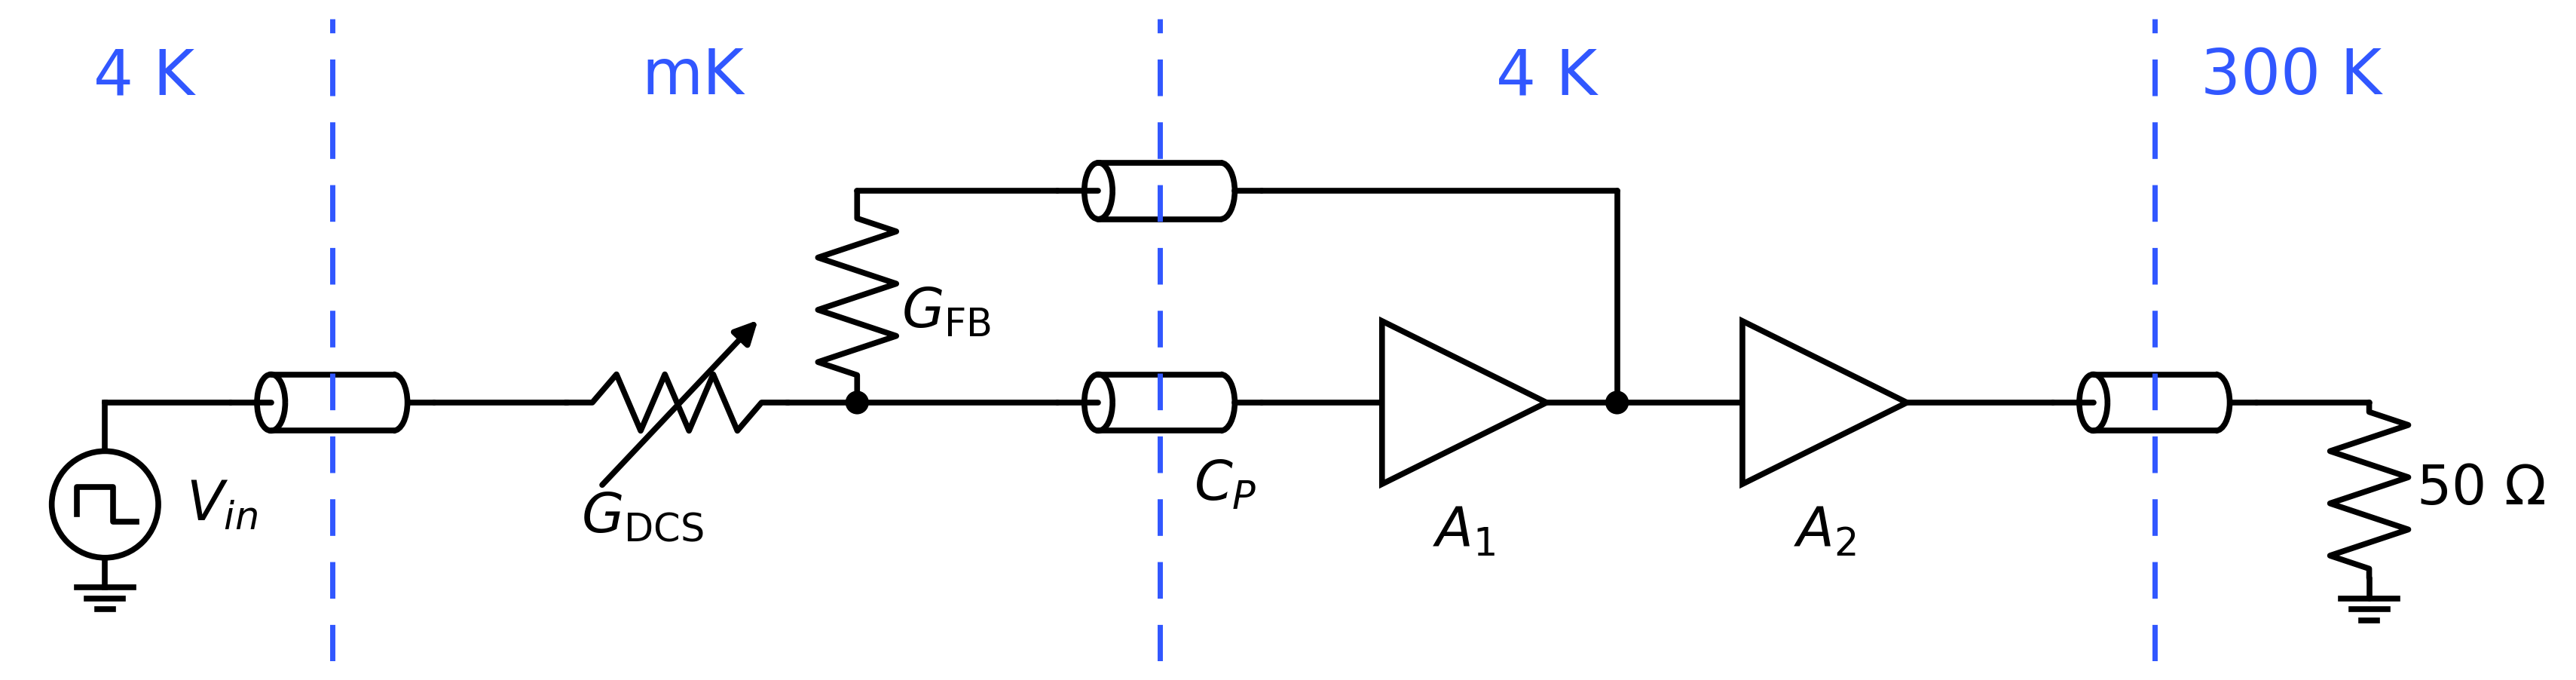

In [18]:
"""Generates a schematic for a cryogenic Transimpedance Amplifier.

This script utilizes the Schemdraw and Matplotlib libraries
to mathematically render an electrical circuit diagram of a Transimpedance
Amplifier (TIA) operating at extremely low temperatures (4 Kelvin).
"""

from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import schemdraw
import schemdraw.elements as elm
from matplotlib import patches, rcParams
from matplotlib.axes import Axes
from matplotlib.transforms import ScaledTranslation


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
DPI: Final[int] = 250
FIGURE_SIZE_IN: Final[tuple[float, float]] = (13.5, 4.1)

WIRE_LW_PT: Final[float] = 2.2
DASH_LW_PT: Final[float] = 2.0
DOT_RADIUS: Final[float] = 0.075

STAGE_BLUE: Final[str] = "#3157FF"
STAGE_TEXT_SIZE_PT: Final[int] = 24
LABEL_SIZE_PT: Final[int] = 21
G_DCS_LABEL_Y_SHIFT_PT: Final[float] = -6.0

MAIN_Y: Final[float] = 0.0
TOP_Y: Final[float] = 1.35

TL_LENGTH: Final[float] = 1.30
TL_RADIUS: Final[float] = 0.18
TL_LEAD_LENGTH: Final[float] = 0.26

X_MIN: Final[float] = -0.55
X_MAX: Final[float] = 15.65
Y_MIN: Final[float] = -1.65
Y_MAX: Final[float] = 2.45

SOURCE_X: Final[float] = 0.0
SOURCE_Y: Final[float] = -0.65
SOURCE_RADIUS: Final[float] = 0.34

TL_LEFT_X: Final[float] = 1.45
TL_MK_X: Final[float] = 6.73
TL_ROOM_X: Final[float] = 13.08

DCS_START_X: Final[float] = 2.95
DCS_END_X: Final[float] = 4.35
NODE_X: Final[float] = 4.80

A1_IN_X: Final[float] = 8.15
A1_OUT_X: Final[float] = 9.20
A1_NODE_X: Final[float] = 9.65
A2_IN_X: Final[float] = 10.45
A2_OUT_X: Final[float] = 11.50

LOAD_X: Final[float] = 14.45
LOAD_TOP_Y: Final[float] = 0.0
LOAD_BOTTOM_Y: Final[float] = -1.12
LOAD_GROUND_Y: Final[float] = -1.25

Point = tuple[float, float]


def tl_edges(center_x: float) -> tuple[float, float]:
    """Calculates the left and right boundary coordinates for a transmission line.

    Args:
        center_x: The horizontal midpoint of the transmission line component.

    Returns:
        A tuple containing the left and right x-coordinates.
    """
    return center_x - TL_LENGTH / 2.0, center_x + TL_LENGTH / 2.0


def add_line(
    drawing: schemdraw.Drawing,
    start: Point,
    end: Point,
) -> None:
    """Draws a straight electrical wire between two specified geometric points.

    Args:
        drawing: The active Schemdraw canvas object.
        start: The initial starting coordinate tuple.
        end: The final terminating coordinate tuple.
    """
    drawing.add(elm.Line().endpoints(start, end))


def add_transmission_line(
    drawing: schemdraw.Drawing,
    center: Point,
) -> None:
    """Inserts a compact coaxial transmission line symbol into the schematic.

    Args:
        drawing: The active Schemdraw canvas object.
        center: The spatial center point for the coaxial element.
    """
    left_x, _ = tl_edges(center[0])

    drawing.add(
        elm.Coax(
            length=TL_LENGTH,
            radius=TL_RADIUS,
            leadlen=TL_LEAD_LENGTH,
        ).at((left_x, center[1]))
    )


def build_backbone() -> schemdraw.Drawing:
    """Constructs the primary electrical topology of the circuit system.

    Returns:
        A populated Schemdraw object containing the foundational wiring and components.
    """
    tl1_left, tl1_right = tl_edges(TL_LEFT_X)
    tl2_left, tl2_right = tl_edges(TL_MK_X)
    tl4_left, tl4_right = tl_edges(TL_ROOM_X)

    drawing = schemdraw.Drawing()
    drawing.config(unit=1.0, lw=WIRE_LW_PT, fontsize=LABEL_SIZE_PT)

    add_line(drawing, (SOURCE_X, MAIN_Y), (tl1_left, MAIN_Y))
    add_transmission_line(drawing, (TL_LEFT_X, MAIN_Y))
    add_line(drawing, (tl1_right, MAIN_Y), (DCS_START_X, MAIN_Y))

    add_line(drawing, (DCS_END_X, MAIN_Y), (NODE_X, MAIN_Y))

    add_line(drawing, (NODE_X, MAIN_Y), (tl2_left, MAIN_Y))
    add_transmission_line(drawing, (TL_MK_X, MAIN_Y))
    add_line(drawing, (tl2_right, MAIN_Y), (A1_IN_X, MAIN_Y))

    drawing.add(
        elm.Resistor().endpoints(
            (NODE_X, MAIN_Y),
            (NODE_X, TOP_Y),
        )
    )

    add_line(drawing, (NODE_X, TOP_Y), (tl2_left, TOP_Y))
    add_transmission_line(drawing, (TL_MK_X, TOP_Y))
    add_line(drawing, (tl2_right, TOP_Y), (A1_NODE_X, TOP_Y))
    add_line(drawing, (A1_NODE_X, TOP_Y), (A1_NODE_X, MAIN_Y))

    add_line(drawing, (A1_OUT_X, MAIN_Y), (A1_NODE_X, MAIN_Y))
    add_line(drawing, (A1_NODE_X, MAIN_Y), (A2_IN_X, MAIN_Y))
    add_line(drawing, (A2_OUT_X, MAIN_Y), (tl4_left, MAIN_Y))

    add_transmission_line(drawing, (TL_ROOM_X, MAIN_Y))

    add_line(drawing, (tl4_right, MAIN_Y), (LOAD_X, MAIN_Y))

    drawing.add(
        elm.Resistor().endpoints(
            (LOAD_X, LOAD_TOP_Y),
            (LOAD_X, LOAD_BOTTOM_Y),
        )
    )
    add_line(drawing, (LOAD_X, LOAD_BOTTOM_Y), (LOAD_X, LOAD_GROUND_Y))

    return drawing


def draw_amplifier(
    ax: Axes,
    left_x: float,
    center_y: float,
    label: str,
    width: float = 1.05,
    height: float = 1.04,
) -> None:
    """Renders a triangular gain block element onto the Matplotlib axes.

    Args:
        ax: The Matplotlib axes object for rendering.
        left_x: The starting horizontal coordinate.
        center_y: The vertical midpoint of the triangle.
        label: The mathematical text string used for identification.
        width: The horizontal span of the amplifier element.
        height: The vertical span of the amplifier element.
    """
    triangle = patches.Polygon(
        [
            (left_x, center_y - height / 2.0),
            (left_x, center_y + height / 2.0),
            (left_x + width, center_y),
        ],
        closed=True,
        facecolor="white",
        edgecolor="black",
        linewidth=WIRE_LW_PT,
        zorder=7,
    )
    ax.add_patch(triangle)

    ax.text(
        left_x + width / 2.0,
        center_y - 0.82,
        rf"${label}$",
        ha="center",
        va="center",
        fontsize=LABEL_SIZE_PT,
        zorder=12,
    )


def draw_ground(
    ax: Axes,
    x_coord: float,
    top_y: float,
    width: float = 0.36,
    gap: float = 0.07,
) -> None:
    """Generates a standard three line Earth ground symbol.

    Args:
        ax: The Matplotlib axes object for rendering.
        x_coord: The horizontal center alignment.
        top_y: The highest vertical coordinate of the symbol.
        width: The total horizontal span of the top line.
        gap: The vertical spacing interval between parallel lines.
    """
    ax.plot(
        [x_coord - width / 2.0, x_coord + width / 2.0],
        [top_y, top_y],
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=8,
    )
    ax.plot(
        [x_coord - 0.32 * width, x_coord + 0.32 * width],
        [top_y - gap, top_y - gap],
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=8,
    )
    ax.plot(
        [x_coord - 0.14 * width, x_coord + 0.14 * width],
        [top_y - 2.0 * gap, top_y - 2.0 * gap],
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=8,
    )


def draw_square_wave_source(ax: Axes) -> None:
    """Illustrates the dynamic voltage pulse source and its ground connection.

    Args:
        ax: The Matplotlib axes object for rendering.
    """
    circle = patches.Circle(
        (SOURCE_X, SOURCE_Y),
        radius=SOURCE_RADIUS,
        facecolor="white",
        edgecolor="black",
        linewidth=WIRE_LW_PT,
        zorder=8,
    )
    ax.add_patch(circle)

    ax.plot(
        [SOURCE_X, SOURCE_X],
        [MAIN_Y, SOURCE_Y + SOURCE_RADIUS],
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=7,
    )
    ax.plot(
        [SOURCE_X, SOURCE_X],
        [SOURCE_Y - SOURCE_RADIUS, -1.18],
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=7,
    )

    wave_x = np.array([-0.18, -0.18, 0.05, 0.05, 0.20]) + SOURCE_X
    wave_y = np.array([-0.06, 0.11, 0.11, -0.11, -0.11]) + SOURCE_Y
    ax.plot(wave_x, wave_y, color="black", linewidth=WIRE_LW_PT, zorder=9)

    draw_ground(ax, SOURCE_X, -1.18)

    ax.text(
        SOURCE_X + 0.52,
        SOURCE_Y,
        r"$V_{in}$",
        ha="left",
        va="center",
        fontsize=LABEL_SIZE_PT,
        zorder=12,
    )


def draw_variable_resistor(ax: Axes) -> None:
    """Constructs the variable conductance structural element.

    Args:
        ax: The Matplotlib axes object for rendering.
    """
    x0 = DCS_START_X
    x1 = DCS_END_X
    y0 = MAIN_Y
    lead = 0.16
    amplitude = 0.18
    peaks = 3

    zig_start = x0 + lead
    zig_end = x1 - lead
    xs = [x0, zig_start]
    ys = [y0, y0]

    vertex_count = 2 * peaks
    for idx in range(vertex_count):
        frac = (idx + 1) / (vertex_count + 1)
        xs.append(zig_start + frac * (zig_end - zig_start))
        ys.append(y0 + amplitude * (1.0 if idx % 2 == 0 else -1.0))

    xs.extend([zig_end, x1])
    ys.extend([y0, y0])

    ax.plot(
        xs,
        ys,
        color="black",
        linewidth=WIRE_LW_PT,
        zorder=8,
    )

    arrow = patches.FancyArrowPatch(
        (x0 + 0.20, y0 - 0.55),
        (x1 - 0.16, y0 + 0.55),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=WIRE_LW_PT,
        color="black",
        zorder=9,
    )
    ax.add_patch(arrow)

    label_transform = ax.transData + ScaledTranslation(
        0.0,
        G_DCS_LABEL_Y_SHIFT_PT / 72.0,
        ax.figure.dpi_scale_trans,
    )

    ax.text(
        3.43,
        -0.63,
        r"$G_{\mathrm{DCS}}$",
        ha="center",
        va="center",
        fontsize=LABEL_SIZE_PT,
        transform=label_transform,
        zorder=12,
    )


def draw_dot(ax: Axes, center: Point) -> None:
    """Places a solid circular marker to indicate an electrical junction.

    Args:
        ax: The Matplotlib axes object for rendering.
        center: The specific coordinate tuple for the junction.
    """
    dot = patches.Circle(
        center,
        radius=DOT_RADIUS,
        facecolor="black",
        edgecolor="black",
        linewidth=0.0,
        zorder=12,
    )
    ax.add_patch(dot)


def draw_labels(ax: Axes) -> None:
    """Superimposes essential text labels denoting thermodynamic stages and parts.

    Args:
        ax: The Matplotlib axes object for rendering.
    """
    stage_labels = [
        (0.25, "4 K"),
        (3.75, "mK"),
        (9.20, "4 K"),
        (13.95, "300 K"),
    ]

    for x_coord, label in stage_labels:
        ax.text(
            x_coord,
            2.08,
            label,
            color=STAGE_BLUE,
            ha="center",
            va="center",
            fontsize=STAGE_TEXT_SIZE_PT,
            zorder=12,
        )

    ax.text(
        NODE_X + 0.28,
        0.58,
        r"$G_{\mathrm{FB}}$",
        ha="left",
        va="center",
        fontsize=LABEL_SIZE_PT,
        zorder=12,
    )
    ax.text(
        7.15,
        -0.52,
        r"$C_P$",
        ha="center",
        va="center",
        fontsize=LABEL_SIZE_PT,
        zorder=12,
    )
    ax.text(
        14.75,
        -0.55,
        r"$50\ \Omega$",
        ha="left",
        va="center",
        fontsize=LABEL_SIZE_PT,
        zorder=12,
    )


def draw_stage_boundaries(ax: Axes) -> None:
    """Overlays vertical lines indicating specific physical temperature zones.

    Args:
        ax: The Matplotlib axes object for rendering.
    """
    for x_coord in (TL_LEFT_X, TL_MK_X, TL_ROOM_X):
        ax.plot(
            [x_coord, x_coord],
            [Y_MIN, Y_MAX],
            color=STAGE_BLUE,
            linewidth=DASH_LW_PT,
            linestyle=(0.0, (7.0, 5.0)),
            zorder=11,
        )


def show_figure(fig: plt.Figure) -> None:
    """Executes the visual display command for the computational notebook.

    Args:
        fig: The complete Matplotlib figure object constructed by the module.
    """
    try:
        from IPython import get_ipython
        from IPython.display import display

        if get_ipython() is not None:
            display(fig)
            plt.close(fig)
            return
    except ImportError:
        pass

    plt.show()


def render_schematic() -> plt.Figure:
    """Orchestrates the complete visual synthesis of the electrical architecture.

    Returns:
        The final composite Matplotlib figure containing the assembled circuit.
    """
    rcParams["figure.dpi"] = DPI
    rcParams["font.family"] = "sans-serif"
    rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
    rcParams["font.weight"] = "normal"
    rcParams["mathtext.fontset"] = "dejavusans"

    schemdraw.use("matplotlib")

    drawing = build_backbone()
    schematic = drawing.draw(show=False)

    fig = schematic.fig
    ax = schematic.ax
    fig.set_size_inches(*FIGURE_SIZE_IN)
    fig.set_dpi(DPI)

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    draw_square_wave_source(ax)
    draw_variable_resistor(ax)

    draw_amplifier(ax, A1_IN_X, MAIN_Y, "A_1")
    draw_amplifier(ax, A2_IN_X, MAIN_Y, "A_2")

    draw_ground(ax, LOAD_X, LOAD_GROUND_Y)

    draw_labels(ax)
    draw_stage_boundaries(ax)
    draw_dot(ax, (NODE_X, MAIN_Y))
    draw_dot(ax, (A1_NODE_X, MAIN_Y))

    fig.tight_layout(pad=0.1)
    return fig


figure = render_schematic()
show_figure(figure)